Input shape: (20, 128, 128, 3)
Target shape: (20, 128, 128, 4)
Output shape: (None, 128, 128, 4)
Epoch 1/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.2508 - loss: 1.3879
Epoch 2/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.2514 - loss: 1.3863
Epoch 3/3
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.2525 - loss: 1.3863
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Segmentation shape: (128, 128)


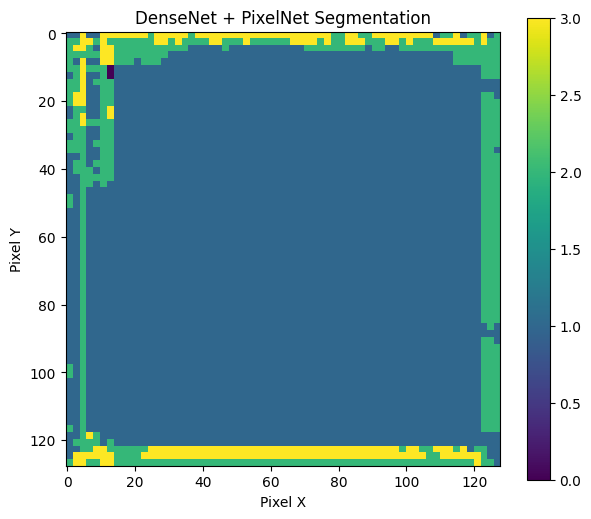


Pixel Class Distribution:
Road : 8
Pedestrian : 13696
Vehicle : 1884
Traffic Sign : 796


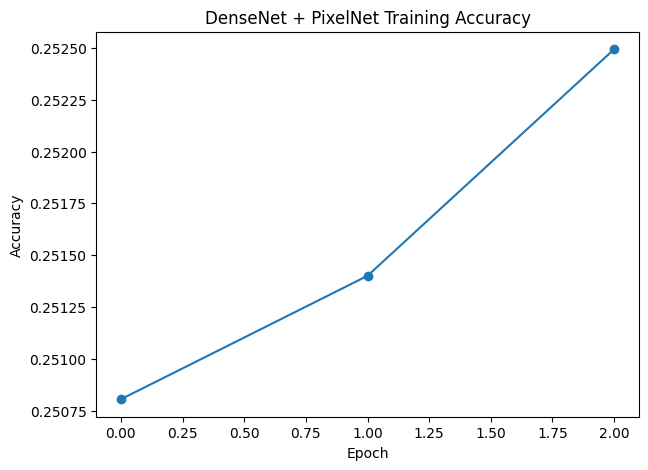

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D
from tensorflow.keras.models import Model

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 128
NUM_CLASSES = 4

classes = [
    "Road",
    "Pedestrian",
    "Vehicle",
    "Traffic Sign"
]

X_train = np.random.rand(
    20, IMG_SIZE, IMG_SIZE, 3
).astype("float32")

y_train = np.random.randint(
    0,
    NUM_CLASSES,
    (20, IMG_SIZE, IMG_SIZE)
)

y_train = tf.keras.utils.to_categorical(
    y_train,
    NUM_CLASSES
)

input_layer = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

densenet = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_tensor=input_layer
)

densenet.trainable = False

x = densenet.output

x = Conv2D(
    128,
    3,
    padding="same",
    activation="relu"
)(x)

x = UpSampling2D(
    (2, 2)
)(x)

x = Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(x)

x = UpSampling2D(
    (2, 2)
)(x)

x = Conv2D(
    32,
    3,
    padding="same",
    activation="relu"
)(x)

x = UpSampling2D(
    (2, 2)
)(x)

x = Conv2D(
    16,
    3,
    padding="same",
    activation="relu"
)(x)

x = UpSampling2D(
    (2, 2)
)(x)

x = Conv2D(
    8,
    3,
    padding="same",
    activation="relu"
)(x)

x = UpSampling2D(
    (2, 2)
)(x)

output = Conv2D(
    NUM_CLASSES,
    1,
    padding="same",
    activation="softmax"
)(x)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Input shape:", X_train.shape)
print("Target shape:", y_train.shape)
print("Output shape:", model.output_shape)

history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=2
)

prediction = model.predict(
    X_train[:1]
)

segmentation = np.argmax(
    prediction[0],
    axis=-1
)

print(
    "Segmentation shape:",
    segmentation.shape
)

plt.figure(figsize=(7, 6))

plt.imshow(segmentation)

plt.title(
    "DenseNet + PixelNet Segmentation"
)

plt.xlabel("Pixel X")
plt.ylabel("Pixel Y")

plt.colorbar()

plt.show()

unique, counts = np.unique(
    segmentation,
    return_counts=True
)

print("\nPixel Class Distribution:")

for class_id, count in zip(
    unique,
    counts
):
    print(
        classes[class_id],
        ":",
        count
    )

plt.figure(figsize=(7, 5))

plt.plot(
    history.history["accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "DenseNet + PixelNet Training Accuracy"
)

plt.show()